In [26]:
from pathlib import Path
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [2]:
FOLDERS = {
    "data/full-drumstick/test2-0": "No fracture hammer 1",
    "data/full-drumstick/test2-100": "100% Fracture hammer 1",
    "data/full-drumstick/test3-0": "No fracture hammer 2",
    "data/full-drumstick/test3-100": "100% Fracture hammer 2"
}

group_data = {}

for folder, label in FOLDERS.items():

    csv_files = sorted(Path(folder).glob("*.csv"))

    if not csv_files:
        print(f"No CSV files found in {folder}")
        continue

    impedances = []
    frequency = None

    for csv_file in csv_files:

        df = pd.read_csv(csv_file)

        if frequency is None:
            frequency = df["frequency"].values

        # Skip incomplete sweeps
        if len(df) != len(frequency):
            print(
                f"Skipping {csv_file.name}: "
                f"{len(df)} rows instead of {len(frequency)}"
            )
            continue

        impedances.append(df["impedance"].values)

    if len(impedances) == 0:
        print(f"No valid files found in {folder}")
        continue

    impedances = np.vstack(impedances)

    group_data[label] = {
        "frequency": frequency,
        "mean": np.mean(impedances, axis=0),
        "std": np.std(impedances, axis=0),
        "raw": impedances,
        "n": len(impedances)
    }

    print(f"{label}: {len(impedances)} files loaded")

No fracture hammer 1: 6 files loaded
100% Fracture hammer 1: 15 files loaded
No fracture hammer 2: 11 files loaded
100% Fracture hammer 2: 14 files loaded


# Create x, and y and split into test and train

In [8]:
X = []
y = []

for group_name, data in group_data.items():

    for sweep in data["raw"]:
        X.append(sweep)
        y.append(group_name)

X = np.array(X)

X = StandardScaler().fit_transform(X)

df = pd.DataFrame(X, columns=frequency)
df["broken"] = ["100% Fracture" in label for label in y]
# split train test

In [10]:
df

,10000.0,11800.0,13600.0,15400.0,17200.0,19000.0,20800.0,22600.0,24400.0,26200.0,...,85600.0,87400.0,89200.0,91000.0,92800.0,94600.0,96400.0,98200.0,100000.0,broken
0,1.156801,1.075081,0.974197,0.888997,0.793106,0.877246,0.837193,0.876285,0.920474,0.811142,...,0.853044,0.854192,0.905624,0.851253,0.776529,0.808257,0.841821,0.845414,0.849543,False
1,1.139289,1.078773,1.059992,0.789648,0.756403,0.824196,0.802993,0.793562,0.911718,0.735881,...,0.790549,0.771924,0.873276,0.784874,0.681822,0.739512,0.763593,0.789438,0.788314,False
2,0.970882,1.111261,0.759900,0.778662,0.762306,0.712656,0.719979,0.738413,0.872944,0.685301,...,0.723040,0.709740,0.809371,0.730599,0.632543,0.676205,0.690059,0.719963,0.695293,False
3,1.089256,1.063760,0.904246,0.709882,0.648091,0.721362,0.645735,0.685044,0.748180,0.648737,...,0.625055,0.594642,0.653945,0.616194,0.526672,0.572893,0.580539,0.607613,0.597955,False
4,1.073791,0.950544,0.844730,0.714658,0.489730,0.634850,0.608612,0.588682,0.655310,0.548187,...,0.528612,0.495766,0.564004,0.516625,0.442359,0.483951,0.473366,0.512731,0.504149,False
5,1.000675,0.918425,0.646086,0.550589,0.502563,0.478150,0.495199,0.461782,0.552434,0.415338,...,0.402466,0.394573,0.463806,0.392849,0.321088,0.373648,0.384577,0.395616,0.395428,False
6,0.126460,-0.073074,-0.773217,-1.262293,-1.483239,-1.616356,-1.718993,-1.777069,-1.789951,-1.846748,...,-1.922177,-1.916271,-1.860472,-1.897609,-1.934555,-1.909311,-1.907903,-1.894661,-1.877106,True
7,0.110995,-0.072089,-0.694570,-1.210708,-1.376211,-1.506448,-1.645918,-1.683079,-1.787449,-1.763870,...,-1.878971,-1.876103,-1.860866,-1.877305,-1.904141,-1.872025,-1.882479,-1.874017,-1.832362,True
8,0.224820,0.002239,-0.696889,-1.183483,-1.474769,-1.541543,-1.616687,-1.735263,-1.748363,-1.790074,...,-1.915619,-1.909705,-1.898736,-1.880429,-1.921080,-1.905815,-1.899689,-1.888706,-1.871611,True
9,0.248927,-0.074920,-0.735536,-1.267786,-1.402647,-1.526308,-1.661994,-1.729333,-1.721784,-1.798605,...,-1.867398,-1.876875,-1.862050,-1.856220,-1.921850,-1.870471,-1.868398,-1.863695,-1.835110,True


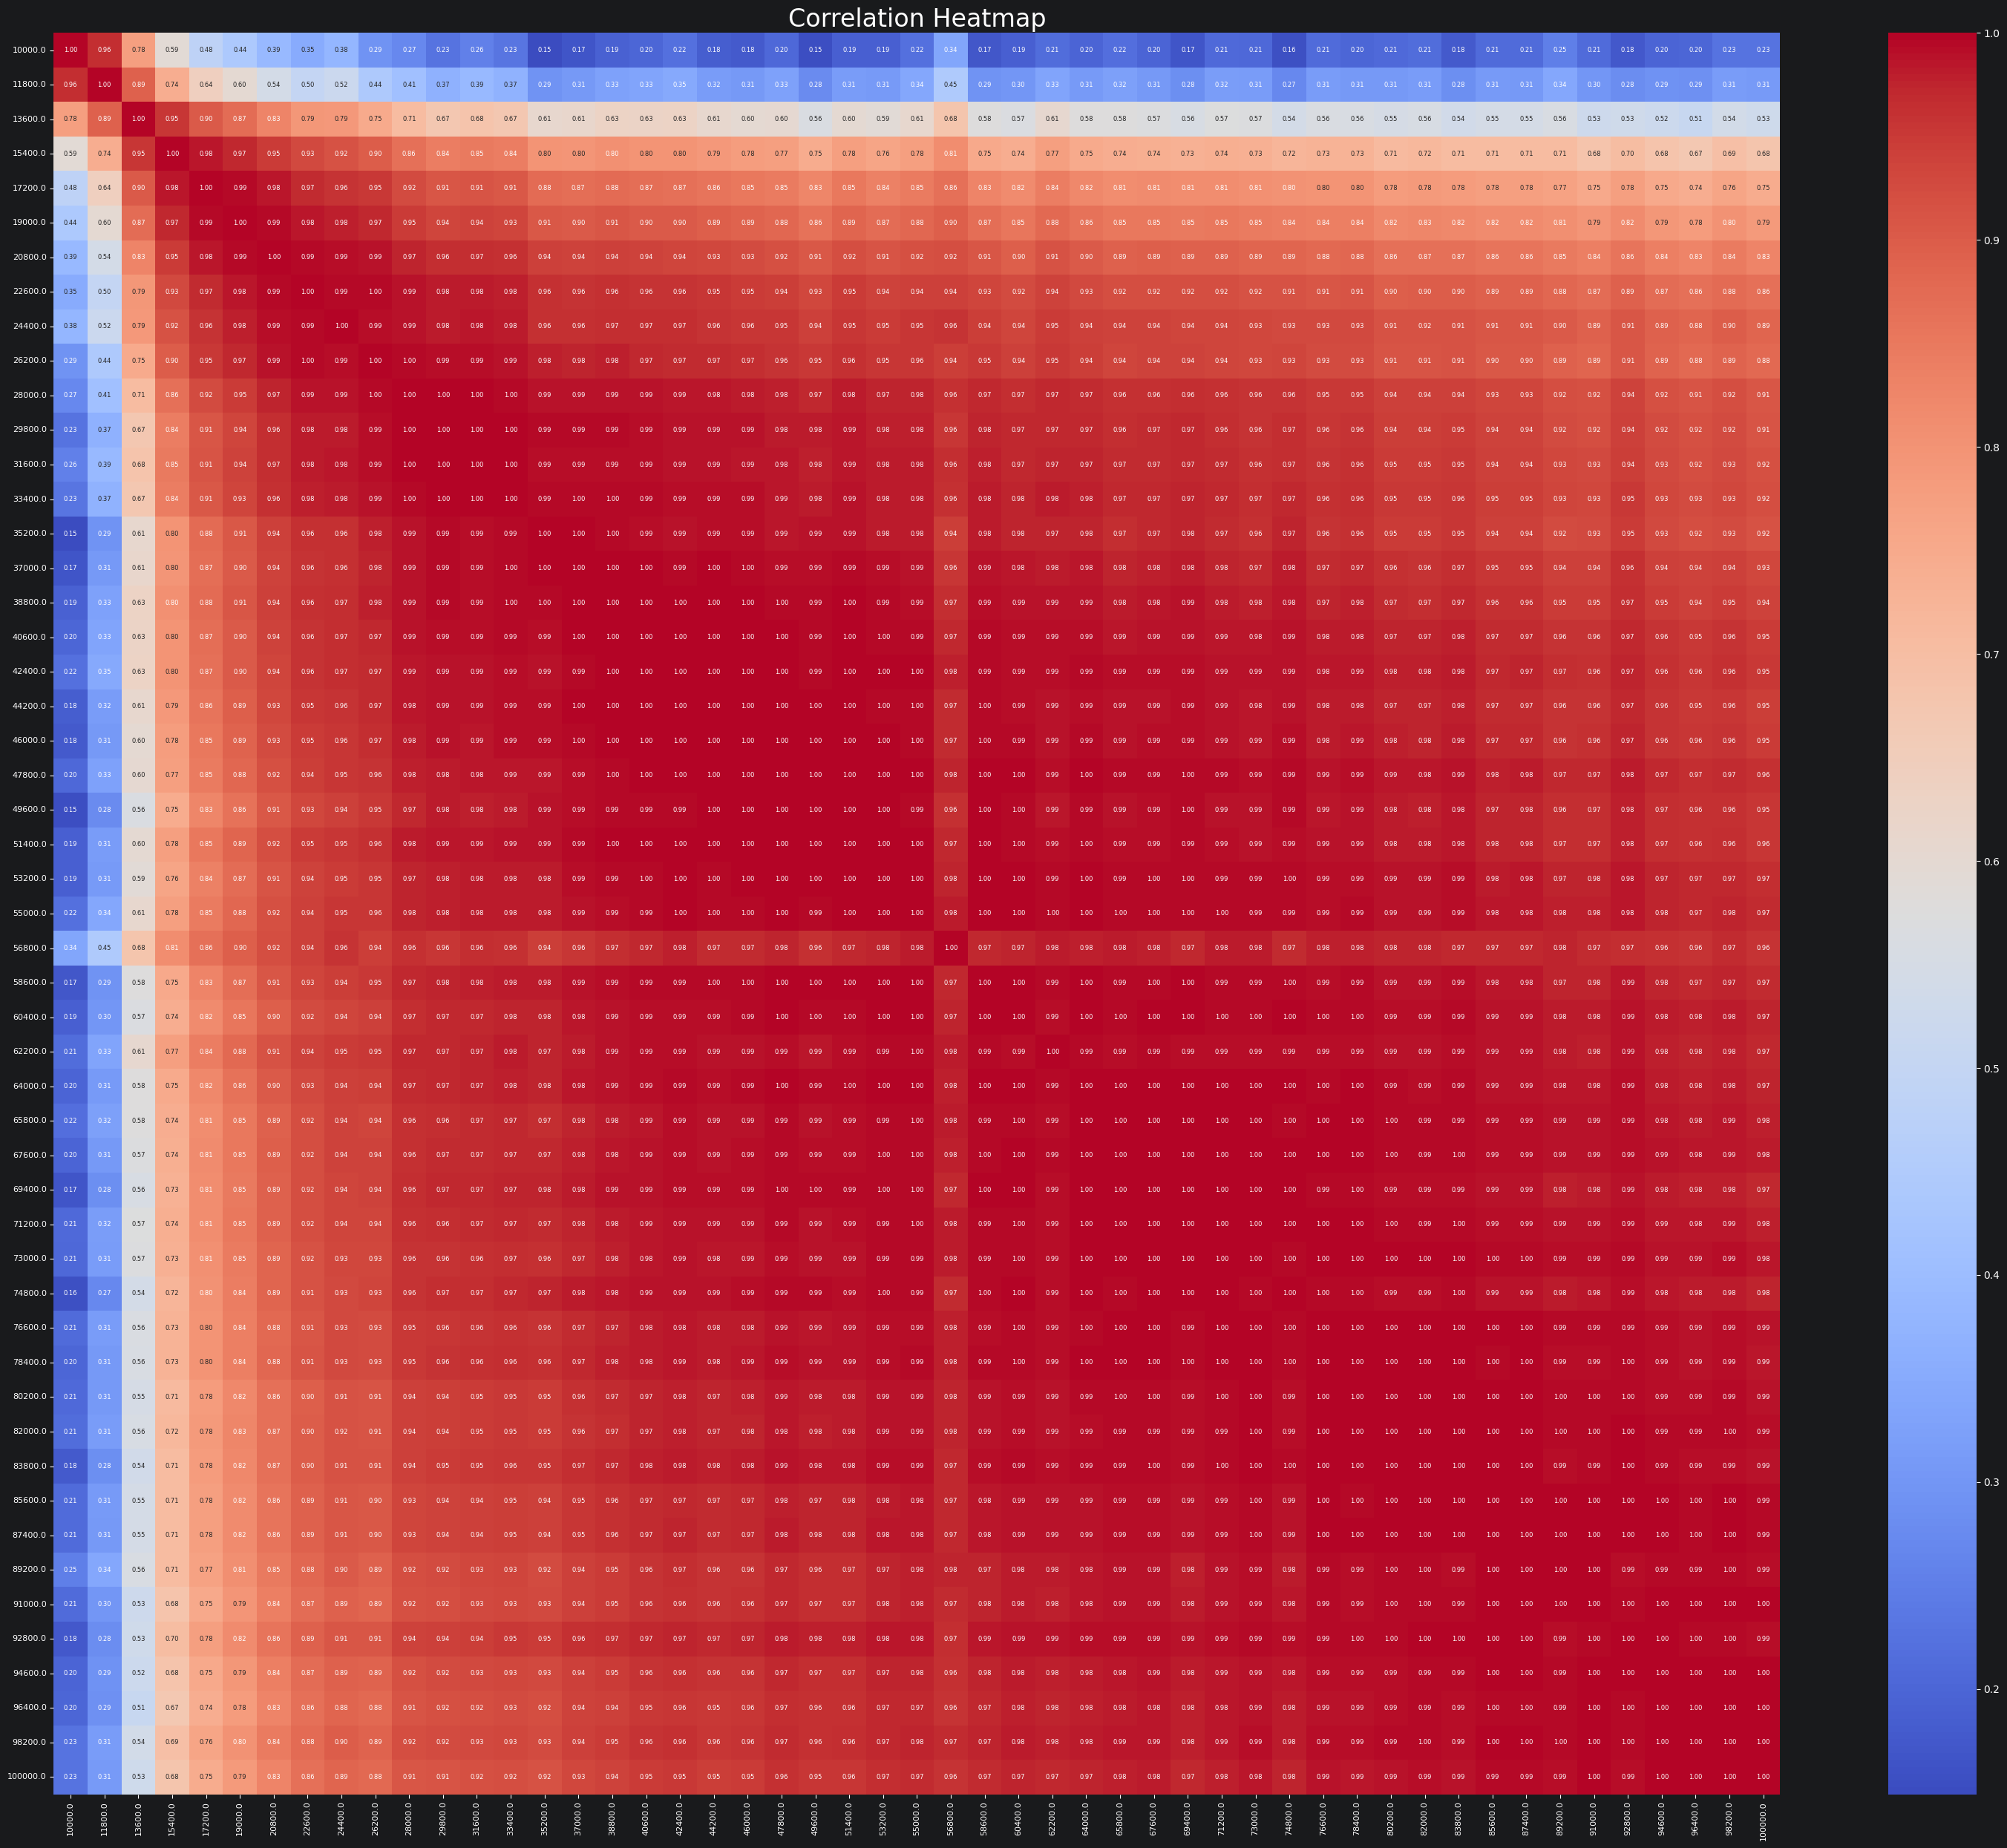

In [15]:
correlation_matrix = df.drop(columns=["broken"]).corr()

plt.figure(figsize=(30, 25))  # Much larger figure

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 6}  # Smaller text
)

plt.title("Correlation Heatmap", fontsize=24)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

In [20]:
# Features (everything except target)
X_ml = df.drop(columns=["broken"])

# Target
y_ml = df["broken"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_ml,
    y_ml,
    test_size=0.2,
    random_state=42,
    stratify=y_ml
)

In [21]:
# Train model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [22]:
# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
[[4 0]
 [0 6]]

Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00         4
        True       1.00      1.00      1.00         6

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [25]:
print(df.shape)
print(df.head())

(46, 52)
    10000.0   11800.0   13600.0   15400.0   17200.0   19000.0   20800.0  \
0  1.156801  1.075081  0.974197  0.888997  0.793106  0.877246  0.837193   
1  1.139289  1.078773  1.059992  0.789648  0.756403  0.824196  0.802993   
2  0.970882  1.111261  0.759900  0.778662  0.762306  0.712656  0.719979   
3  1.089256  1.063760  0.904246  0.709882  0.648091  0.721362  0.645735   
4  1.073791  0.950544  0.844730  0.714658  0.489730  0.634850  0.608612   

    22600.0   24400.0   26200.0  ...   85600.0   87400.0   89200.0   91000.0  \
0  0.876285  0.920474  0.811142  ...  0.853044  0.854192  0.905624  0.851253   
1  0.793562  0.911718  0.735881  ...  0.790549  0.771924  0.873276  0.784874   
2  0.738413  0.872944  0.685301  ...  0.723040  0.709740  0.809371  0.730599   
3  0.685044  0.748180  0.648737  ...  0.625055  0.594642  0.653945  0.616194   
4  0.588682  0.655310  0.548187  ...  0.528612  0.495766  0.564004  0.516625   

    92800.0   94600.0   96400.0   98200.0  100000.0  broken

In [28]:
model = Pipeline([
    ("pca", PCA(n_components=0.95)),  # keep 95% variance
    ("classifier", LogisticRegression(max_iter=1000))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    X_ml,
    y_ml,
    cv=cv,
    scoring="accuracy"
)

print("Fold accuracies:", scores)
print("Mean accuracy:", scores.mean())
print("Std:", scores.std())

Fold accuracies: [0.9        0.77777778 1.         1.         1.        ]
Mean accuracy: 0.9355555555555556
Std: 0.08788319970348972
